### Minimal reimplementation on synthetic time series

The aim of this first notebook is to  validate the core mechanism in a controlled setting where the periodic structure is known.

This to confirn whether our reimplementation behaves as expected before moving to real benchmark datasets.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt


### 0. Synthetic Time Series Creation

In [2]:
# Set random seed for reproducibility      
np.random.seed(42)

In [3]:
T = 2000          # total number of time steps
period = 24      # true cycle length
noise_std = 0.15 # noise level
# Time index
t = np.arange(T)
# Periodic component: daily-like cycle
cycle = np.sin(2 * np.pi * t / period)
trend = 0.0005 * t # slight upward trend 
noise = np.random.normal(loc=0.0, scale=noise_std, size=T) # Gaussian noise
# Final synthetic time series
x = cycle + trend + noise
# Add channel dimension: [T, C]
# Here C = 1 because this is a univariate time series
x = x.reshape(-1, 1)
print("Time series shape:", x.shape)


Time series shape: (2000, 1)


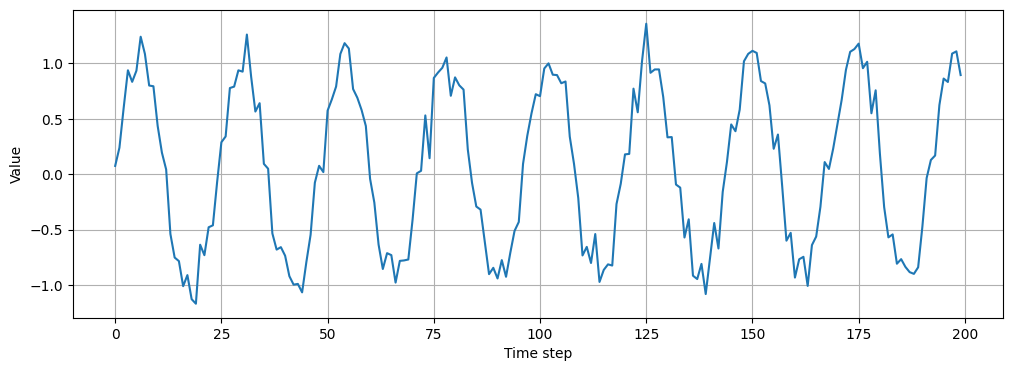

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(x[:200])
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

### 1. Sliding Window torch dataset creation 

We prepare the dataset for a Pytorch friendly setup to test the linear baseline and CycleNet architecture on the same training loop. 

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowDataset(Dataset):
    def __init__(self, series, seq_len, pred_len, cycle_len, start_index=0):
        """
        series: numpy array of shape [T, C]
        seq_len: lookback length L

        pred_len: forecasting horizon H
        cycle_len: assumed cycle period
        start_index: original global index where this series slice starts
        """
        self.series = torch.tensor(series, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.cycle_len = cycle_len
        self.start_index = start_index

        self.num_samples = len(series) - seq_len - pred_len + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x_window = self.series[idx : idx + self.seq_len]
        y_target = self.series[idx + self.seq_len : idx + self.seq_len + self.pred_len]

        # Global time index of the first element in the input window
        global_idx = self.start_index + idx

        # Correct phase inside the cycle
        cycle_index = global_idx % self.cycle_len

        return x_window, y_target, cycle_index

In [9]:
seq_len = 6
pred_len = 192
cycle_len = 24
batch_size = 32

train_ratio = 0.8
train_size = int(len(x) * train_ratio)

x_train = x[:train_size]

test_start_index = train_size - seq_len - pred_len
x_test = x[test_start_index:]

train_dataset = SlidingWindowDataset(
    x_train,
    seq_len=seq_len,
    pred_len=pred_len,
    cycle_len=cycle_len,
    start_index=0
)

test_dataset = SlidingWindowDataset(
    x_test,
    seq_len=seq_len,
    pred_len=pred_len,
    cycle_len=cycle_len,
    start_index=test_start_index
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

x_batch, y_batch, cycle_idx = next(iter(train_loader))

print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)
print("cycle_idx shape:", cycle_idx.shape)
print("Example cycle indices:", cycle_idx[:10])

Train samples: 1403
Test samples: 401
x_batch shape: torch.Size([32, 6, 1])
y_batch shape: torch.Size([32, 192, 1])
cycle_idx shape: torch.Size([32])
Example cycle indices: tensor([11,  2, 13,  4, 15,  3,  2,  0, 19, 16])


### 2. Linear Baseline 

We pursue baseline forecasting using Least Squares Method with Pytorch so that the training loop is similar to CycleNet, this method will try to forecast all the time series components as one, implicitly. 
Later we will compare this method to the CycleNet architecture to test improvements.

In [10]:
import torch.nn as nn

class LinearBaseline(nn.Module):
    def __init__(self, seq_len, pred_len):
        super().__init__()

        self.linear = nn.Linear(seq_len, pred_len)

    def forward(self, x):
        """
        x: [B, L, C]
        returns: [B, H, C]
        """
        x = x.permute(0, 2, 1)          # [B, C, L]
        y_hat = self.linear(x)          # [B, C, H]
        y_hat = y_hat.permute(0, 2, 1)  # [B, H, C]

        return y_hat

In [11]:
# train the linear baseline on the training data 
from tqdm import tqdm

# Device setup
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

# Model
linear_model = LinearBaseline(seq_len=seq_len, pred_len=pred_len).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(linear_model.parameters(), lr=1e-3)

# Training settings
num_epochs = 100

train_losses = []

for epoch in range(num_epochs):
    linear_model.train()
    epoch_loss = 0.0

    for x_batch, y_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = linear_model(x_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train MSE: {epoch_loss:.6f}")

Using device: mps
Epoch 01/100 | Train MSE: 0.925431
Epoch 02/100 | Train MSE: 0.734217
Epoch 03/100 | Train MSE: 0.599397
Epoch 04/100 | Train MSE: 0.501241
Epoch 05/100 | Train MSE: 0.426772
Epoch 06/100 | Train MSE: 0.368920
Epoch 07/100 | Train MSE: 0.322807
Epoch 08/100 | Train MSE: 0.285279
Epoch 09/100 | Train MSE: 0.254409
Epoch 10/100 | Train MSE: 0.228726
Epoch 11/100 | Train MSE: 0.207448
Epoch 12/100 | Train MSE: 0.189458
Epoch 13/100 | Train MSE: 0.174401
Epoch 14/100 | Train MSE: 0.161806
Epoch 15/100 | Train MSE: 0.151135
Epoch 16/100 | Train MSE: 0.142193
Epoch 17/100 | Train MSE: 0.134731
Epoch 18/100 | Train MSE: 0.128418
Epoch 19/100 | Train MSE: 0.123151
Epoch 20/100 | Train MSE: 0.118735
Epoch 21/100 | Train MSE: 0.115061
Epoch 22/100 | Train MSE: 0.111958
Epoch 23/100 | Train MSE: 0.109381
Epoch 24/100 | Train MSE: 0.107235
Epoch 25/100 | Train MSE: 0.105421
Epoch 26/100 | Train MSE: 0.103976
Epoch 27/100 | Train MSE: 0.102671
Epoch 28/100 | Train MSE: 0.101611
Ep

In [12]:
# Evaluating on test set: MAE and MSE 

def evaluate_model(model, data_loader, device):
    model.eval()

    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_values = 0

    with torch.no_grad():
        for x_batch, y_batch, _ in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(x_batch)

            squared_error = (y_pred - y_batch) ** 2
            absolute_error = torch.abs(y_pred - y_batch)

            total_squared_error += squared_error.sum().item()
            total_absolute_error += absolute_error.sum().item()
            total_values += y_batch.numel()

    mse = total_squared_error / total_values
    mae = total_absolute_error / total_values

    return mse, mae


linear_test_mse, linear_test_mae = evaluate_model(
    linear_model,
    test_loader,
    device
)

print(f"Linear Baseline Test MSE: {linear_test_mse:.6f}")
print(f"Linear Baseline Test MAE: {linear_test_mae:.6f}")

Linear Baseline Test MSE: 0.280361
Linear Baseline Test MAE: 0.425558


### 3. Implenting CycleNet Linear 

Linear Baseline Test MSE: 0.027061 <cd>

Linear Baseline Test MAE: 0.130337


We test CycleNet architecture with simple linear predictor for residuals and compare to linear baseline, verifying paper claim: The stable periodic patterns present in time series data serve as the foundation for conducting long-horizon forecasts.

In [13]:
class CycleNetLinear(nn.Module):
    def __init__(self, seq_len, pred_len, num_channels, cycle_len):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_channels = num_channels
        self.cycle_len = cycle_len

        # Learnable cycle pattern: [cycle_len, C]
        self.cycle = nn.Parameter(
            torch.zeros(cycle_len, num_channels)
        )

        # Same Linear backbone as the baseline
        self.linear = nn.Linear(seq_len, pred_len)

    def forward(self, x, cycle_index):
        """
        x: [B, L, C]
        cycle_index: [B]
        returns: [B, H, C]
        """

        B, L, C = x.shape

        # Indices for the past cycle component
        past_offsets = torch.arange(L, device=x.device)
        past_indices = (cycle_index[:, None] + past_offsets[None, :]) % self.cycle_len

        # Indices for the future cycle component
        future_offsets = torch.arange(self.pred_len, device=x.device)
        future_indices = (
            cycle_index[:, None] + L + future_offsets[None, :]
        ) % self.cycle_len

        # Retrieve learned cycle values
        past_cycle = self.cycle[past_indices]        # [B, L, C]
        future_cycle = self.cycle[future_indices]    # [B, H, C]

        # Residualize input
        residual_input = x - past_cycle

        # Forecast residual with Linear backbone
        residual_input = residual_input.permute(0, 2, 1)      # [B, C, L]
        residual_forecast = self.linear(residual_input)       # [B, C, H]
        residual_forecast = residual_forecast.permute(0, 2, 1) # [B, H, C]

        # Add future cycle back
        y_hat = residual_forecast + future_cycle

        return y_hat

In [14]:
cyclenet_model = CycleNetLinear(
    seq_len=seq_len,
    pred_len=pred_len,
    num_channels=x.shape[1],
    cycle_len=cycle_len
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(cyclenet_model.parameters(), lr=1e-3)

num_epochs = 100
cyclenet_train_losses = []

for epoch in range(num_epochs):
    cyclenet_model.train()
    epoch_loss = 0.0

    for x_batch, y_batch, cycle_idx in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        cycle_idx = cycle_idx.to(device)

        optimizer.zero_grad()

        y_pred = cyclenet_model(x_batch, cycle_idx)

        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= len(train_loader.dataset)
    cyclenet_train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | CycleNet-Linear Train MSE: {epoch_loss:.6f}")

Epoch 01/100 | CycleNet-Linear Train MSE: 0.867939
Epoch 02/100 | CycleNet-Linear Train MSE: 0.647068
Epoch 03/100 | CycleNet-Linear Train MSE: 0.504586
Epoch 04/100 | CycleNet-Linear Train MSE: 0.408580
Epoch 05/100 | CycleNet-Linear Train MSE: 0.340253
Epoch 06/100 | CycleNet-Linear Train MSE: 0.290004
Epoch 07/100 | CycleNet-Linear Train MSE: 0.251796
Epoch 08/100 | CycleNet-Linear Train MSE: 0.222050
Epoch 09/100 | CycleNet-Linear Train MSE: 0.198440
Epoch 10/100 | CycleNet-Linear Train MSE: 0.179383
Epoch 11/100 | CycleNet-Linear Train MSE: 0.163790
Epoch 12/100 | CycleNet-Linear Train MSE: 0.150925
Epoch 13/100 | CycleNet-Linear Train MSE: 0.140187
Epoch 14/100 | CycleNet-Linear Train MSE: 0.131223
Epoch 15/100 | CycleNet-Linear Train MSE: 0.123664
Epoch 16/100 | CycleNet-Linear Train MSE: 0.117214
Epoch 17/100 | CycleNet-Linear Train MSE: 0.111722
Epoch 18/100 | CycleNet-Linear Train MSE: 0.106985
Epoch 19/100 | CycleNet-Linear Train MSE: 0.102879
Epoch 20/100 | CycleNet-Linear 

In [15]:
def evaluate_cyclenet(model, data_loader, device):
    model.eval()

    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_values = 0

    with torch.no_grad():
        for x_batch, y_batch, cycle_idx in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            cycle_idx = cycle_idx.to(device)

            y_pred = model(x_batch, cycle_idx)

            squared_error = (y_pred - y_batch) ** 2
            absolute_error = torch.abs(y_pred - y_batch)

            total_squared_error += squared_error.sum().item()
            total_absolute_error += absolute_error.sum().item()
            total_values += y_batch.numel()

    mse = total_squared_error / total_values
    mae = total_absolute_error / total_values

    return mse, mae


cyclenet_test_mse, cyclenet_test_mae = evaluate_cyclenet(
    cyclenet_model,
    test_loader,
    device
)

print(f"CycleNet-Linear Test MSE: {cyclenet_test_mse:.6f}")
print(f"CycleNet-Linear Test MAE: {cyclenet_test_mae:.6f}")

CycleNet-Linear Test MSE: 0.026780
CycleNet-Linear Test MAE: 0.129842


In [17]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Baseline", "CycleNet-Linear"],
    "Test MSE": [linear_test_mse, cyclenet_test_mse],
    "Test MAE": [linear_test_mae, cyclenet_test_mae]
})

results

,Model,Test MSE,Test MAE
0,Linear Baseline,0.280361,0.425558
1,CycleNet-Linear,0.026780,0.129842


On a clean stationary periodic signal, a direct Linear model can already learn the periodic mapping very well, hence the CycleNet architecture ties with the linear model

instead, when the linear model only sees a partial cycle, CycleNet improves strongly

seq_len = 6
pred_len = 192
cycle_len = 24

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>Test MSE</th>
      <th>Test MAE</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Linear Baseline</td>
      <td>0.280361</td>
      <td>0.425558</td>
    </tr>
    <tr>
      <th>1</th>
      <td>CycleNet-Linear</td>
      <td>0.026780</td>
      <td>0.129842</td>
    </tr>
  </tbody>
</table>
</div>



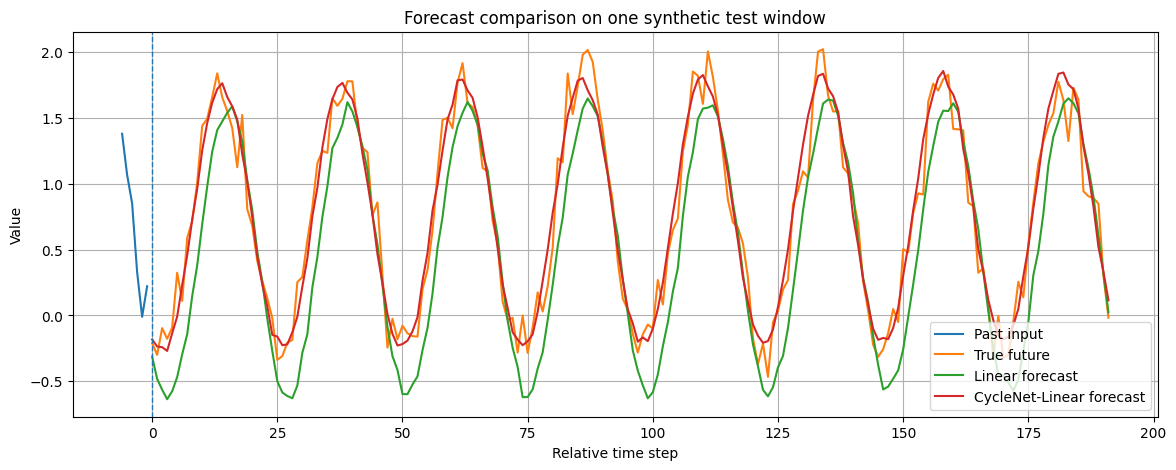

In [18]:
# Plot one test example: past window, true future, Linear prediction, CycleNet prediction

linear_model.eval()
cyclenet_model.eval()

x_batch, y_batch, cycle_idx = next(iter(test_loader))

x_batch = x_batch.to(device)
y_batch = y_batch.to(device)
cycle_idx = cycle_idx.to(device)

with torch.no_grad():
    y_pred_linear = linear_model(x_batch)
    y_pred_cyclenet = cyclenet_model(x_batch, cycle_idx)

# Select one example from the batch
example_id = 0

past = x_batch[example_id, :, 0].detach().cpu().numpy()
true_future = y_batch[example_id, :, 0].detach().cpu().numpy()
linear_future = y_pred_linear[example_id, :, 0].detach().cpu().numpy()
cyclenet_future = y_pred_cyclenet[example_id, :, 0].detach().cpu().numpy()

past_time = np.arange(-seq_len, 0)
future_time = np.arange(pred_len)

plt.figure(figsize=(14, 5))

plt.plot(past_time, past, label="Past input")
plt.plot(future_time, true_future, label="True future")
plt.plot(future_time, linear_future, label="Linear forecast")
plt.plot(future_time, cyclenet_future, label="CycleNet-Linear forecast")

plt.axvline(x=0, linestyle="--", linewidth=1)
plt.title("Forecast comparison on one synthetic test window")
plt.xlabel("Relative time step")
plt.ylabel("Value")


plt.legend()
plt.grid(True)
plt.show()

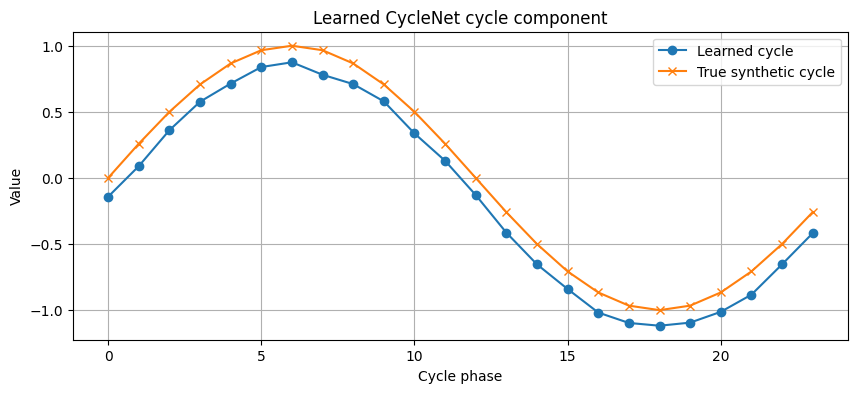

In [19]:
# Plot the learned cycle component

learned_cycle = cyclenet_model.cycle.detach().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(learned_cycle[:, 0], marker="o", label="Learned cycle")

# If the synthetic clean cycle variable still exists, compare against one true period
try:
    true_cycle_one_period = cycle[:cycle_len]
    plt.plot(true_cycle_one_period, marker="x", label="True synthetic cycle")
except NameError:
    pass

plt.title("Learned CycleNet cycle component")
plt.xlabel("Cycle phase")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

The learned cycle component closely follows the shape of the true synthetic periodic pattern. This confirms that the learnable cycle table captures meaningful phase-dependent structure. The match is not exact, which is expected because the final forecast is produced jointly by the cycle component and the Linear residual backbone.